## Task 1: inspect prior distributions

In [1]:
# COLAB users: load simulations and data
system("ls", TRUE)

system("wget https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-task1.csv", TRUE)

system("wget https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-task2_no_mig.csv", TRUE)

system("wget https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-task2_im.csv", TRUE)

system("wget https://raw.githubusercontent.com/manolofperez/Physalia_MLPopGen/refs/heads/main/2026/Day1/Notebooks/mosquito-observed.csv", TRUE)

# Then you just need to load it, as the files will be in the root directory of your Colab.

[1] "sample_data"

character(0)

character(0)

character(0)

character(0)

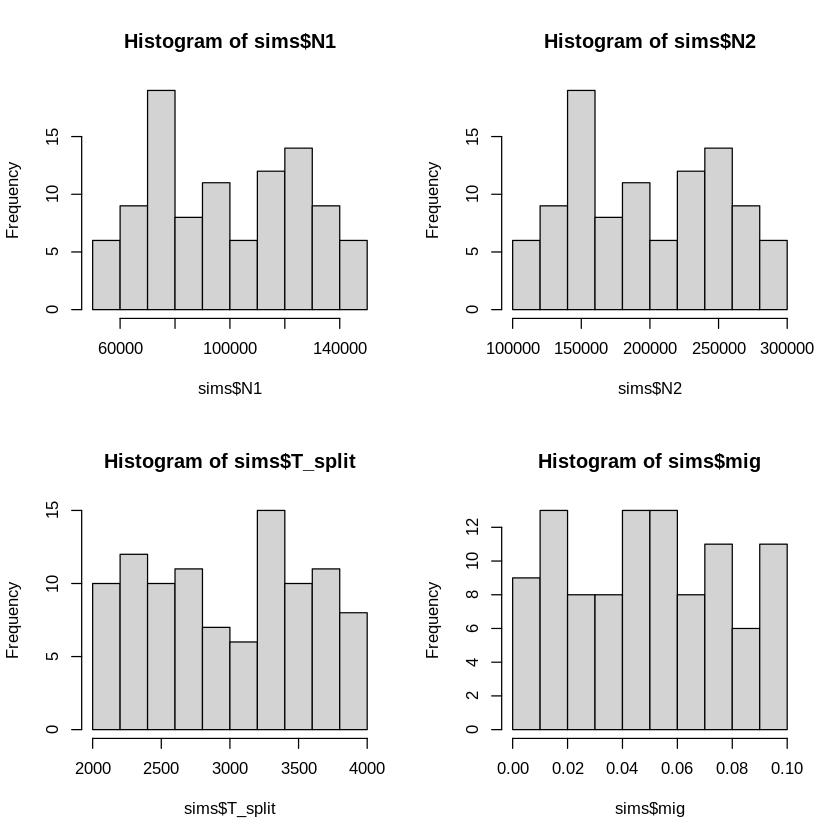

In [2]:
sims <- read.csv("mosquito-task1.csv", head=T)

# check prior distributions
par(mfrow=c(2,2))
hist(sims$N1)
hist(sims$N2)
hist(sims$T_split)
hist(sims$mig)


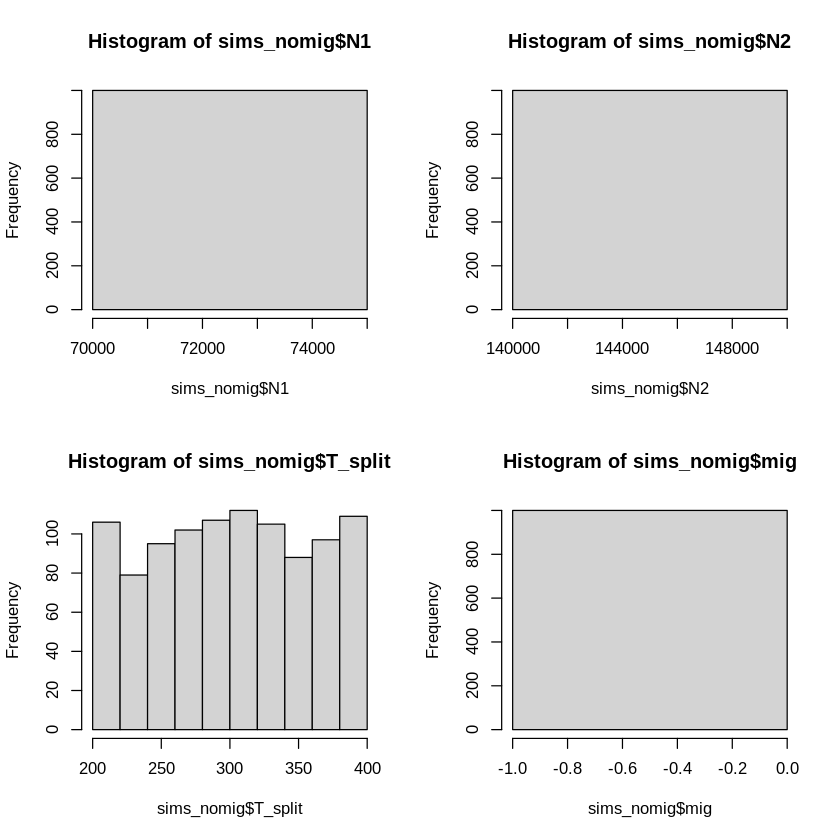

In [3]:
sims_nomig <- read.csv("mosquito-task2_no_mig.csv", head=T)

# check prior distributions
par(mfrow=c(2,2))
hist(sims_nomig$N1)
hist(sims_nomig$N2)
hist(sims_nomig$T_split)
hist(sims_nomig$mig)


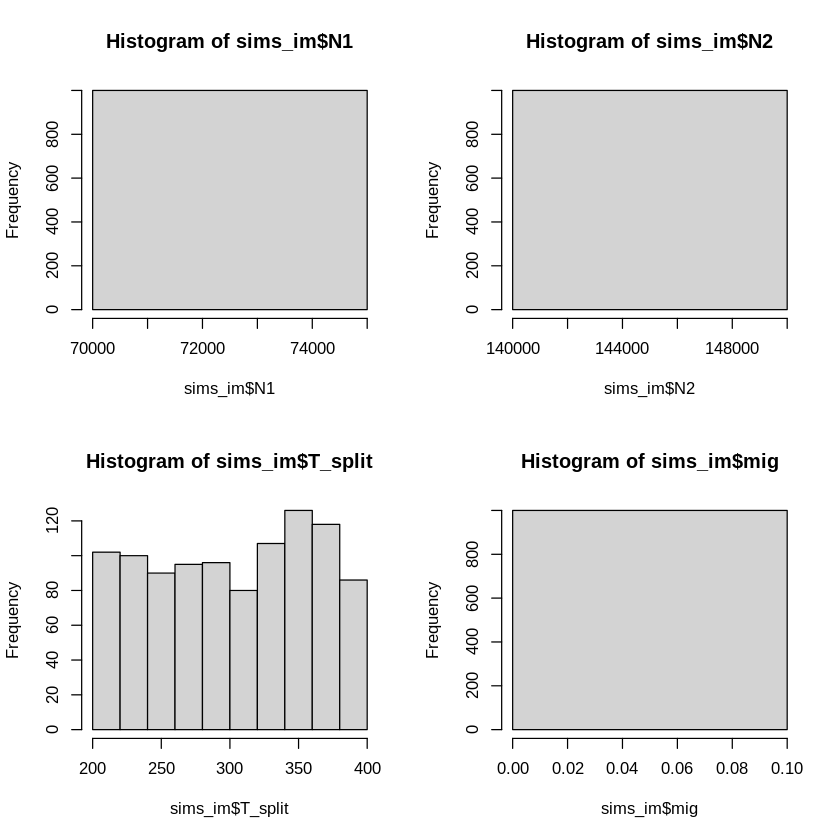

In [4]:
sims_im <- read.csv("mosquito-task2_im.csv", head=T)

# check prior distributions
par(mfrow=c(2,2))
hist(sims_im$N1)
hist(sims_im$N2)
hist(sims_im$T_split)
hist(sims_im$mig)

## Task 2: perform ABC model selection

In [25]:
# load observed summary stats
obs <- read.csv("mosquito-observed.csv", head=T)

# merge obs with retained sims to scale them
sumstats_modsel <- scale(rbind(obs,sims_nomig[5:12],sims_im[5:12]))
head(sumstats_modsel)

Fst,dxy,segsites1,segsites2,pi1,pi2,tajima1,tajima2
-1.23089840,-20.63101419,-7.28379964,5.5622504,-20.55844740,-20.6389245,-27.091737682,-24.4305574
0.31112249,0.54275564,0.65375146,1.2936505,0.55657410,0.5096165,0.184828162,-0.4966154
0.04703325,-0.00799973,-0.47713141,0.6409137,0.02548519,-0.0441686,0.428299663,-0.5544953
1.76503765,1.36951101,1.00378663,0.2990040,1.26662112,1.3638902,0.799950256,1.1514007
0.78994694,-0.01250721,0.04343372,-0.4345479,0.03177861,-0.1023803,0.009088389,0.2347340
0.42326791,-0.73231667,-1.10539967,-0.3475163,-0.76312083,-0.7237704,-0.079577573,-0.4804096


In [6]:
# load ABC library
install.packages("abc")
library(abc)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘SparseM’, ‘MatrixModels’, ‘abc.data’, ‘quantreg’, ‘locfit’


Loading required package: abc.data

Loading required package: nnet

Loading required package: quantreg

Loading required package: SparseM

Loading required package: MASS

Loading required package: locfit

locfit 1.5-9.12 	 2025-03-05



In [26]:
# 1. Create an index vector
models <- c(rep("Isolation", 1000), rep("IM", 1000))

# 2. Run the model selection
mod_sel <- postpr(target = sumstats_modsel[1,],
                  index = models,
                  sumstat = sumstats_modsel[-1,],
                  tol = 0.05,
                  method = "rejection")

# 3. View the results
summary(mod_sel)

Call: 
postpr(target = sumstats_modsel[1, ], index = models, sumstat = sumstats_modsel[-1, 
    ], tol = 0.05, method = "rejection")
Data:
 postpr.out$values (100 posterior samples)
Models a priori:
 IM, Isolation
Models a posteriori:
 IM, Isolation

Proportion of accepted simulations (rejection):
       IM Isolation 
     0.41      0.59 

Bayes factors:
              IM Isolation
IM        1.0000    0.6949
Isolation 1.4390    1.0000




## Task 2: perform ABC parameter estimation

In [12]:
# find useful summary stats which correlate with T_split
cat("Fst: ", cor(sims_nomig$Fst, sims_nomig$T_split), "\n")
cat("dxy: ", cor(sims_nomig$dxy, sims_nomig$T_split), "\n")
cat("segsites1: ", cor(sims_nomig$segsites1, sims_nomig$T_split), "\n")
cat("segsites2: ", cor(sims_nomig$segsites2, sims_nomig$T_split), "\n")
cat("pi1: ", cor(sims_nomig$pi1, sims_nomig$T_split), "\n")
cat("pi2: ", cor(sims_nomig$pi2, sims_nomig$T_split), "\n")
cat("tajima1: ", cor(sims_nomig$tajima1, sims_nomig$T_split), "\n")
cat("tajima2: ", cor(sims_nomig$tajima2, sims_nomig$T_split), "\n")

Fst:  0.5529581 
dxy:  0.03916826 
segsites1:  0.1410381 
segsites2:  0.5071152 
pi1:  0.0254273 
pi2:  0.03011611 
tajima1:  -0.1108713 
tajima2:  -0.4194161 


In [13]:
# check if simulated retained summary stats contain the observed one
quantile(sims_nomig$Fst); cat(obs$Fst)
quantile(sims_nomig$segsites1); cat(obs$segsites1)
quantile(sims_nomig$segsites2); cat(obs$segsites2)


0%           25%           50%           75%          100% 
-8.553455e-05  5.642221e-04  7.314192e-04  9.119480e-04  1.589464e-03

-0.0001438266

0%        25%        50%        75%       100% 
0.03698667 0.03943333 0.03988333 0.04042000 0.04181333

0.03447079

0%        25%        50%        75%       100% 
0.04486000 0.04736667 0.04804667 0.04859333 0.05038000

0.05331101

In [16]:
# merge obs with retained sims to scale them
sumstats <- scale(rbind(obs[c(1,3,4)],sims_nomig[,c(5,7,8)]))
head(sumstats)

Fst,segsites1,segsites2
-3.4518911,-7.27266975,5.95389776
-0.9064162,0.62617135,0.83989964
-1.3423587,-0.49919641,0.05788804
1.4936191,0.97449946,-0.35173708
-0.1160017,0.01883002,-1.23056916
-0.7212933,-1.12440072,-1.12630095


In [17]:
est <- abc(target=sumstats[1,], param=sims_nomig$T_split, sumstat=sumstats[-1,], tol=0.05, method="rejection")

Warning message in abc(target = sumstats[1, ], param = sims_nomig$T_split, sumstat = sumstats[-1, :
“No parameter names are given, using P1, P2, ...”


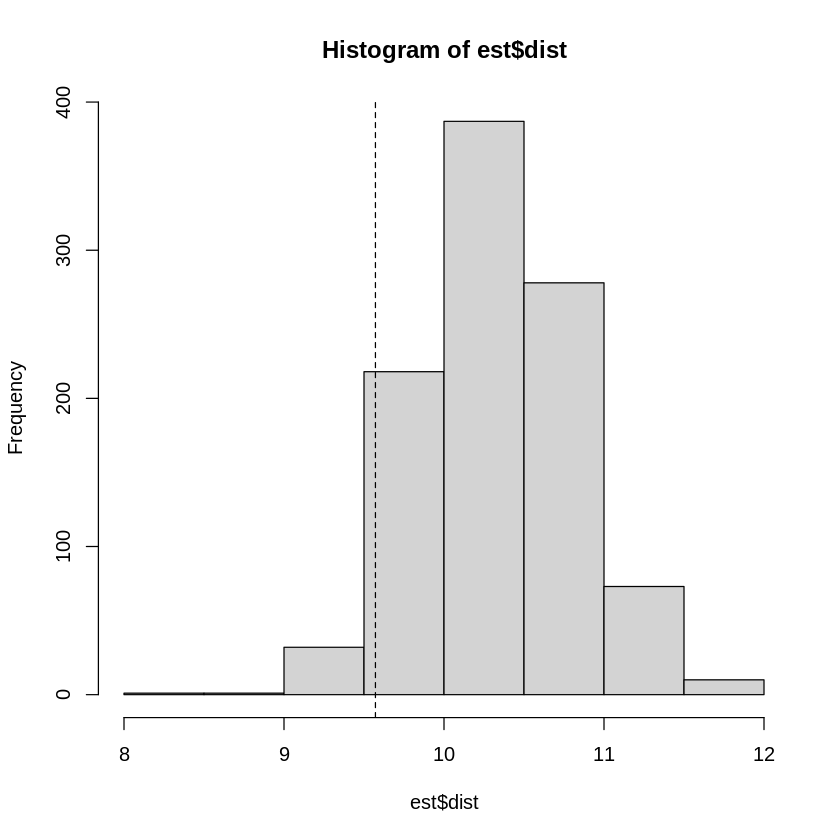

In [18]:
# check distances in the acceptance region
hist(est$dist)
abline(v=max(est$dist[which(est$region)]), lty=2)

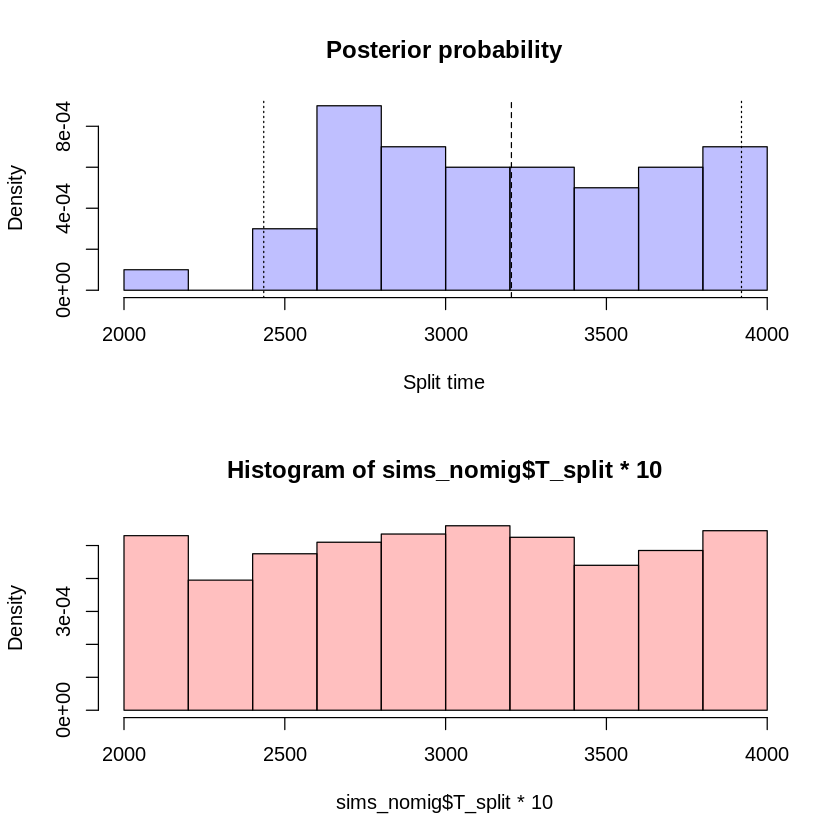

In [22]:
# posterior distribution
par(mfrow=c(2,1))
hist(est$unadj.values * 10, freq=FALSE, xlim=range(sims_nomig$T_split * 10), col=rgb(0,0,1,1/4), main="Posterior probability", xlab="Split time")

# MAP
map <- mean(est$unadj.values * 10)
abline(v=map, lty=2)

# confidence intervals
hpd <- quantile(x=est$unadj.values * 10, probs=c(0.025,0.975))
abline(v=hpd, lty=3)

# prior
hist(sims_nomig$T_split * 10, freq=FALSE, xlim=range(sims_nomig$T_split * 10), col=rgb(1,0,0,1/4))


## Task 3: Evaluate the performance with cross-validation

Confusion matrix based on 100 samples for each model.

$tol0.05
           IM Isolation
IM        100         0
Isolation   4        96


Mean model posterior probabilities (rejection)

$tol0.05
              IM Isolation
IM        0.8909    0.1091
Isolation 0.1228    0.8772



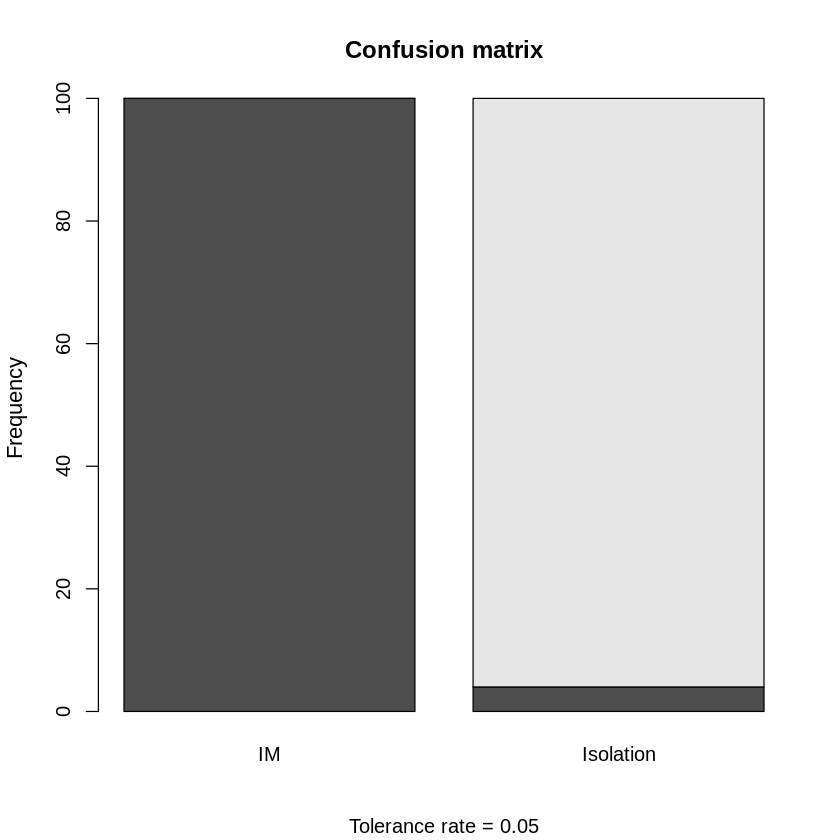

In [27]:
# Cross-validation for model selection
# nval = number of cross-validation points (e.g., 100)
cv_model <- cv4postpr(index = models,
                      sumstat = sumstats_modsel[-1,],
                      nval = 100,
                      tol = 0.05,
                      method = "rejection")

# 1. View the Confusion Matrix
summary(cv_model)

# 2. Visualize it
plot(cv_model)

Prediction error based on a cross-validation sample of 100



          P1
0.05 1.13085

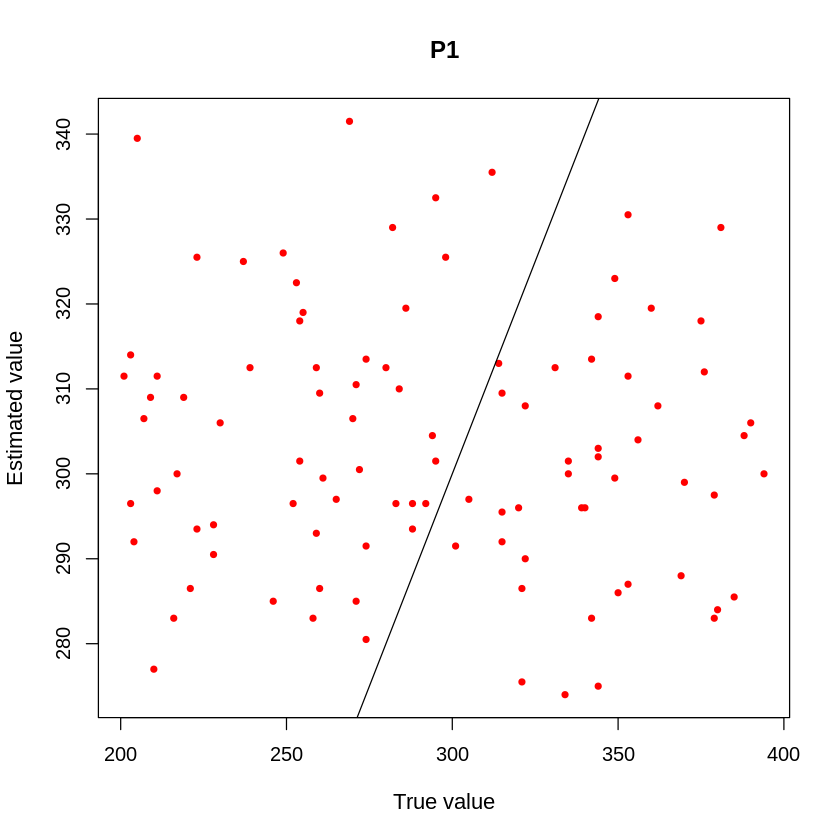

In [24]:
# Cross-validation for parameter estimation
cv_param <- cv4abc(param = sims_im$T_split,
                   sumstat = sumstats[-1,],
                   nval = 100,
                   tol = 0.05,
                   method = "rejection")

# This shows the "Prediction Error"
# A value near 0 means high precision; near 1 means the ABC is no better than guessing.
summary(cv_param)
plot(cv_param)